# 10_resnet18

Unified ResNet18 compression experiment.

## Main idea
For each training compression level:
- train on that level's train split
- validate on that level's val split
- save the best checkpoint
- test on all compression levels

## Compression levels
- orig
- CRF18
- CRF23
- CRF28
- CRF35
- CRF51

## Outputs
Saved under:
- `cholec80/outputs/resnet18/checkpoints/`
- `cholec80/outputs/resnet18/predictions/`
- `cholec80/outputs/resnet18/metrics/`
- `cholec80/outputs/resnet18/plots/`
- `cholec80/outputs/resnet18/gradcam/`

## Key results
This notebook produces:
- full train-vs-test compression heatmaps
- stacked metric curves across test compression
- diagonal-only matched train/test compression curves
- selected confusion matrices
- selected Grad-CAM comparisons

In [26]:
# ============================================================
# 1. Imports
# ============================================================
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from tqdm.auto import tqdm

In [27]:
# ============================================================
# 2. Reproducibility and device
# ============================================================
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        try:
            torch.mps.manual_seed(seed)
        except Exception:
            pass

set_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: mps


In [28]:
# ============================================================
# 3. Paths
# ============================================================
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "cholec80"
FRAME_PREP_DIR = DATA_ROOT / "outputs" / "frame_prep"

MODEL_OUT_DIR = DATA_ROOT / "outputs" / "resnet18"
CHECKPOINT_DIR = MODEL_OUT_DIR / "checkpoints"
PREDICTIONS_DIR = MODEL_OUT_DIR / "predictions"
METRICS_DIR = MODEL_OUT_DIR / "metrics"
PLOTS_DIR = MODEL_OUT_DIR / "plots"
GRADCAM_DIR = MODEL_OUT_DIR / "gradcam"

for p in [CHECKPOINT_DIR, PREDICTIONS_DIR, METRICS_DIR, PLOTS_DIR, GRADCAM_DIR]:
    p.mkdir(parents=True, exist_ok=True)

METADATA_PATHS = {
    "orig": FRAME_PREP_DIR / "pilot_metadata_orig.csv",
    "CRF18": FRAME_PREP_DIR / "pilot_metadata_CRF18.csv",
    "CRF23": FRAME_PREP_DIR / "pilot_metadata_CRF23.csv",
    "CRF28": FRAME_PREP_DIR / "pilot_metadata_CRF28.csv",
    "CRF35": FRAME_PREP_DIR / "pilot_metadata_CRF35.csv",
    "CRF51": FRAME_PREP_DIR / "pilot_metadata_CRF51.csv",
}

In [29]:
# ============================================================
# 4. Config
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 5e-4
DROPOUT_P = 0.3

PHASE_MAP = {
    "Preparation": 0,
    "CalotTriangleDissection": 1,
    "ClippingCutting": 2,
    "GallbladderDissection": 3,
    "GallbladderPackaging": 4,
    "CleaningCoagulation": 5,
    "GallbladderRetraction": 6,
}
ID_TO_PHASE = {v: k for k, v in PHASE_MAP.items()}
NUM_CLASSES = len(PHASE_MAP)

LEVELS = ["orig", "CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]
CRF_X = [0, 18, 23, 28, 35, 51]
LEVEL_TO_X = dict(zip(LEVELS, CRF_X))

In [30]:
# ============================================================
# 5. Load metadata
# ============================================================
metadata = {}

for level, path in METADATA_PATHS.items():
    df = pd.read_csv(path)
    df = df[df["image_exists"] == True].copy().reset_index(drop=True)
    metadata[level] = df
    print(level, df.shape)

orig (46099, 9)
CRF18 (46099, 9)
CRF23 (46099, 9)
CRF28 (46099, 9)
CRF35 (46099, 9)
CRF51 (46099, 9)


In [31]:
# ============================================================
# 6. Quick split counts
# ============================================================
for level in LEVELS:
    df = metadata[level]
    print(f"\n{level}")
    print(df["split"].value_counts().sort_index())


orig
split
test     10081
train    26956
val       9062
Name: count, dtype: int64

CRF18
split
test     10081
train    26956
val       9062
Name: count, dtype: int64

CRF23
split
test     10081
train    26956
val       9062
Name: count, dtype: int64

CRF28
split
test     10081
train    26956
val       9062
Name: count, dtype: int64

CRF35
split
test     10081
train    26956
val       9062
Name: count, dtype: int64

CRF51
split
test     10081
train    26956
val       9062
Name: count, dtype: int64


In [32]:
# ============================================================
# 7. Transforms
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [33]:
# ============================================================
# 8. Dataset
# ============================================================
class CholecFrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = int(row["phase_id"])

        meta = {
            "compression": row["compression"],
            "video": row["video"],
            "split": row["split"],
            "frame_idx": int(row["frame_idx"]),
            "second_idx": int(row["second_idx"]),
            "phase_name": row["phase_name"],
            "image_path": row["image_path"],
        }

        return img, label, meta

In [34]:
# ============================================================
# 9. DataLoader builder
# ============================================================
def make_loaders_for_train_level(train_level):
    train_df = metadata[train_level][metadata[train_level]["split"] == "train"].reset_index(drop=True)
    val_df = metadata[train_level][metadata[train_level]["split"] == "val"].reset_index(drop=True)

    class_counts = train_df["phase_id"].value_counts().sort_index().to_dict()
    weights_per_class = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = train_df["phase_id"].map(weights_per_class).values

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        CholecFrameDataset(train_df, transform=train_tfms),
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    val_loader = DataLoader(
        CholecFrameDataset(val_df, transform=eval_tfms),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    test_loaders = {}
    for test_level in LEVELS:
        test_df = metadata[test_level][metadata[test_level]["split"] == "test"].reset_index(drop=True)
        test_loaders[test_level] = DataLoader(
            CholecFrameDataset(test_df, transform=eval_tfms),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=False,
        )

    return train_df, val_df, train_loader, val_loader, test_loaders

In [35]:
# ============================================================
# 10. Model
# ============================================================
def build_model(num_classes=NUM_CLASSES, dropout_p=DROPOUT_P):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes)
    )
    return model

In [36]:
# ============================================================
# 11. Training / evaluation helpers
# ============================================================
def run_epoch(model, loader, criterion, optimizer=None, train=False):
    model.train() if train else model.eval()

    total_loss = 0.0
    all_y = []
    all_pred = []
    all_prob = []
    all_meta = []

    for images, labels, metas in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = torch.argmax(probs, dim=1)

        all_y.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())
        all_prob.extend(probs.detach().cpu().numpy())

        for i in range(len(labels)):
            meta = {
                k: metas[k][i] if isinstance(metas[k], list) else metas[k][i]
                for k in metas
            }
            all_meta.append(meta)

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_y), np.array(all_pred), np.array(all_prob), all_meta


def multiclass_metrics(y_true, y_pred, y_prob, num_classes=NUM_CLASSES):
    acc = accuracy_score(y_true, y_pred)

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    prec_per, rec_per, f1_per, support_per = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=list(range(num_classes)),
        zero_division=0,
    )

    y_true_onehot = np.eye(num_classes)[y_true]

    try:
        auc_macro = roc_auc_score(
            y_true_onehot, y_prob, average="macro", multi_class="ovr"
        )
    except Exception:
        auc_macro = np.nan

    return {
        "accuracy": float(acc),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "auc_macro_ovr": None if np.isnan(auc_macro) else float(auc_macro),
        "per_class_f1": {ID_TO_PHASE[i]: float(f1_per[i]) for i in range(num_classes)},
        "per_class_precision": {ID_TO_PHASE[i]: float(prec_per[i]) for i in range(num_classes)},
        "per_class_recall": {ID_TO_PHASE[i]: float(rec_per[i]) for i in range(num_classes)},
        "support": {ID_TO_PHASE[i]: int(support_per[i]) for i in range(num_classes)},
    }


def save_prediction_table(y_true, y_pred, y_prob, metas, save_path):
    rows = []
    for i in range(len(y_true)):
        row = dict(metas[i])
        row["y_true"] = int(y_true[i])
        row["y_pred"] = int(y_pred[i])
        row["y_true_name"] = ID_TO_PHASE[int(y_true[i])]
        row["y_pred_name"] = ID_TO_PHASE[int(y_pred[i])]

        for c in range(NUM_CLASSES):
            row[f"prob_{ID_TO_PHASE[c]}"] = float(y_prob[i, c])

        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False)
    return df

In [37]:
# ============================================================
# 12. Cross-compression experiment
# ============================================================
all_results = {}
all_history = []
all_pred_tables = {}

for train_level in LEVELS:
    print("\n" + "=" * 70)
    print(f"TRAIN LEVEL: {train_level}")
    print("=" * 70)

    train_df, val_df, train_loader, val_loader, test_loaders = make_loaders_for_train_level(train_level)

    model = build_model().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    checkpoint_path = CHECKPOINT_DIR / f"best_resnet18_train_{train_level}.pth"

    best_val_f1 = -1.0
    train_level_history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_y, train_pred, train_prob, train_meta = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, train=True
        )

        val_loss, val_y, val_pred, val_prob, val_meta = run_epoch(
            model, val_loader, criterion, optimizer=None, train=False
        )

        train_metrics = multiclass_metrics(train_y, train_pred, train_prob)
        val_metrics = multiclass_metrics(val_y, val_pred, val_prob)

        scheduler.step(val_metrics["f1_macro"])

        row = {
            "train_level": train_level,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_metrics["accuracy"],
            "val_acc": val_metrics["accuracy"],
            "train_precision_macro": train_metrics["precision_macro"],
            "val_precision_macro": val_metrics["precision_macro"],
            "train_recall_macro": train_metrics["recall_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
        }
        train_level_history.append(row)
        all_history.append(row)

        print(
            f"[{train_level}] Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_f1={train_metrics['f1_macro']:.4f} val_f1={val_metrics['f1_macro']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} val_acc={val_metrics['accuracy']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            torch.save({
                "train_level": train_level,
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "best_val_f1": best_val_f1,
                "epoch": epoch,
                "history": train_level_history,
            }, checkpoint_path)
            print("Saved best checkpoint:", checkpoint_path)

    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    for test_level in LEVELS:
        print(f"Evaluating train={train_level} -> test={test_level}")

        loss, y_true, y_pred, y_prob, metas = run_epoch(
            model, test_loaders[test_level], criterion, optimizer=None, train=False
        )

        metrics = multiclass_metrics(y_true, y_pred, y_prob)
        metrics["loss"] = float(loss)
        metrics["train_level"] = train_level
        metrics["test_level"] = test_level

        pred_path = PREDICTIONS_DIR / f"train_{train_level}__test_{test_level}.csv"
        pred_df = save_prediction_table(y_true, y_pred, y_prob, metas, pred_path)

        all_results[(train_level, test_level)] = metrics
        all_pred_tables[(train_level, test_level)] = pred_df


TRAIN LEVEL: orig


  0%|          | 0/843 [00:00<?, ?it/s]

  0%|          | 0/284 [00:00<?, ?it/s]

[orig] Epoch 01 | train_loss=0.3769 val_loss=1.8450 | train_f1=0.8714 val_f1=0.4004 | train_acc=0.8715 val_acc=0.4744
Saved best checkpoint: /Users/niranjani/Desktop/video-compression-project/cholec80/outputs/resnet18/checkpoints/best_resnet18_train_orig.pth


  0%|          | 0/843 [00:00<?, ?it/s]

...

  0%|          | 0/316 [00:00<?, ?it/s]

Evaluating train=CRF51 -> test=CRF35


  0%|          | 0/316 [00:00<?, ?it/s]

Evaluating train=CRF51 -> test=CRF51


  0%|          | 0/316 [00:00<?, ?it/s]

In [38]:
# ============================================================
# 13. Save long-form results
# ============================================================
history_df = pd.DataFrame(all_history)
history_df.to_csv(METRICS_DIR / "training_history_all_train_levels.csv", index=False)

result_rows = []
for (train_level, test_level), m in all_results.items():
    result_rows.append({
        "train_level": train_level,
        "test_level": test_level,
        "accuracy": m["accuracy"],
        "precision_macro": m["precision_macro"],
        "recall_macro": m["recall_macro"],
        "f1_macro": m["f1_macro"],
        "auc_macro_ovr": m["auc_macro_ovr"],
        "loss": m["loss"],
    })

results_df = pd.DataFrame(result_rows).sort_values(["train_level", "test_level"]).reset_index(drop=True)
results_df.to_csv(METRICS_DIR / "cross_compression_metrics.csv", index=False)

with open(METRICS_DIR / "cross_compression_metrics.json", "w") as f:
    json.dump(result_rows, f, indent=2)

results_df

,train_level,test_level,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,loss
0,CRF18,CRF18,0.689019,0.639358,0.687920,0.657593,0.928983,1.292033
1,CRF18,CRF23,0.686341,0.636389,0.684933,0.654245,0.928704,1.297188
2,CRF18,CRF28,0.684853,0.635564,0.685597,0.653321,0.928096,1.314431
3,CRF18,CRF35,0.671858,0.622157,0.680859,0.641612,0.924333,1.398607
4,CRF18,CRF51,0.537447,0.450404,0.501384,0.443780,0.849135,1.535968
5,CRF18,orig,0.688821,0.639593,0.687314,0.657841,0.929206,1.283698
6,CRF23,CRF18,0.671759,0.669237,0.668390,0.646487,0.923148,1.318092
7,CRF23,CRF23,0.672255,0.669156,0.671291,0.648312,0.922889,1.324170
8,CRF23,CRF28,0.670271,0.668913,0.669958,0.646347,0.922393,1.351663
9,CRF23,CRF35,0.652316,0.660362,0.657348,0.626958,0.916956,1.510870


In [39]:
# ============================================================
# 14. Pivot tables
# ============================================================
pivot_acc = results_df.pivot(index="train_level", columns="test_level", values="accuracy").loc[LEVELS, LEVELS]
pivot_prec = results_df.pivot(index="train_level", columns="test_level", values="precision_macro").loc[LEVELS, LEVELS]
pivot_f1 = results_df.pivot(index="train_level", columns="test_level", values="f1_macro").loc[LEVELS, LEVELS]
pivot_auc = results_df.pivot(index="train_level", columns="test_level", values="auc_macro_ovr").loc[LEVELS, LEVELS]

print("Macro F1 matrix:")
display(pivot_f1)

Macro F1 matrix:


test_level,orig,CRF18,CRF23,CRF28,CRF35,CRF51
train_level,,,,,,
orig,0.624160,0.622353,0.622052,0.622497,0.615613,0.363062
CRF18,0.657841,0.657593,0.654245,0.653321,0.641612,0.443780
CRF23,0.649884,0.646487,0.648312,0.646347,0.626958,0.423977
CRF28,0.671563,0.666432,0.666591,0.669902,0.658249,0.493230
CRF35,0.653216,0.651350,0.653758,0.655340,0.642546,0.386842
CRF51,0.535781,0.537953,0.536704,0.536548,0.535978,0.548672


## Heatmaps

In [1]:
# ============================================================
# 15. Heatmap helper
# ============================================================
def plot_heatmap(df, title, save_name, vmin=None, vmax=None):
    arr = df.values

    plt.figure(figsize=(8, 6))
    im = plt.imshow(arr, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(im)

    plt.xticks(range(len(df.columns)), df.columns)
    plt.yticks(range(len(df.index)), df.index)
    plt.xlabel("Test Compression")
    plt.ylabel("Train Compression")
    plt.title(title)

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val:.3f}", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / save_name, dpi=200)
    plt.show()

plot_heatmap(pivot_acc, "Accuracy: Train vs Test Compression", "heatmap_accuracy.png")
plot_heatmap(pivot_prec, "Macro Precision: Train vs Test Compression", "heatmap_precision.png")
plot_heatmap(pivot_f1, "Macro F1: Train vs Test Compression", "heatmap_f1.png")
plot_heatmap(pivot_auc, "Macro AUC: Train vs Test Compression", "heatmap_auc.png")

NameError: name 'pivot_acc' is not defined

## Stacked metric-vs-test-compression plots

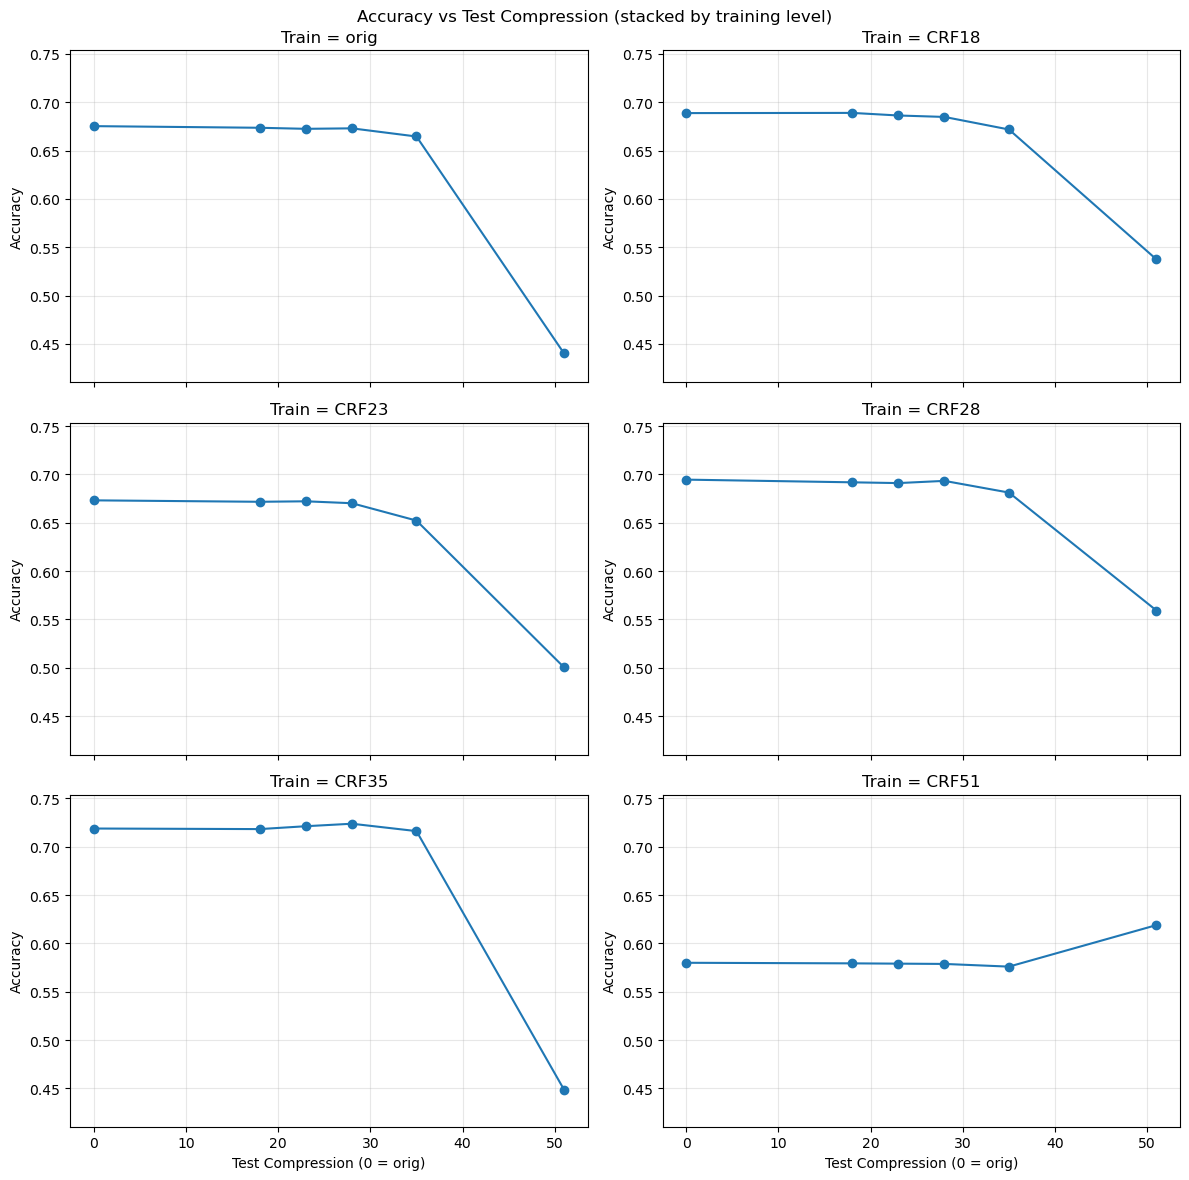

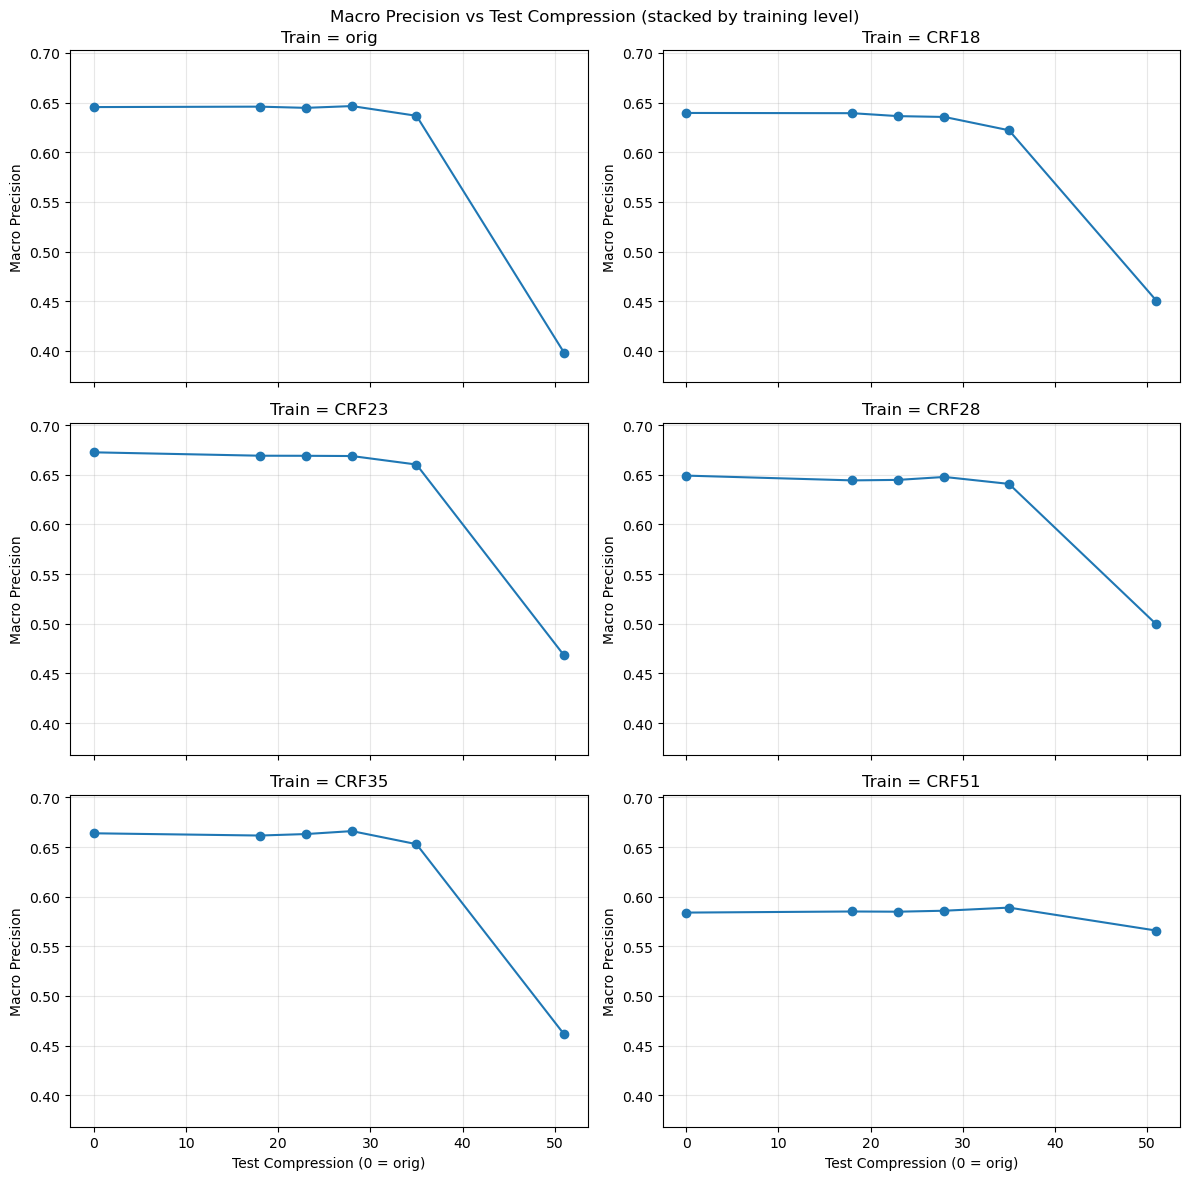

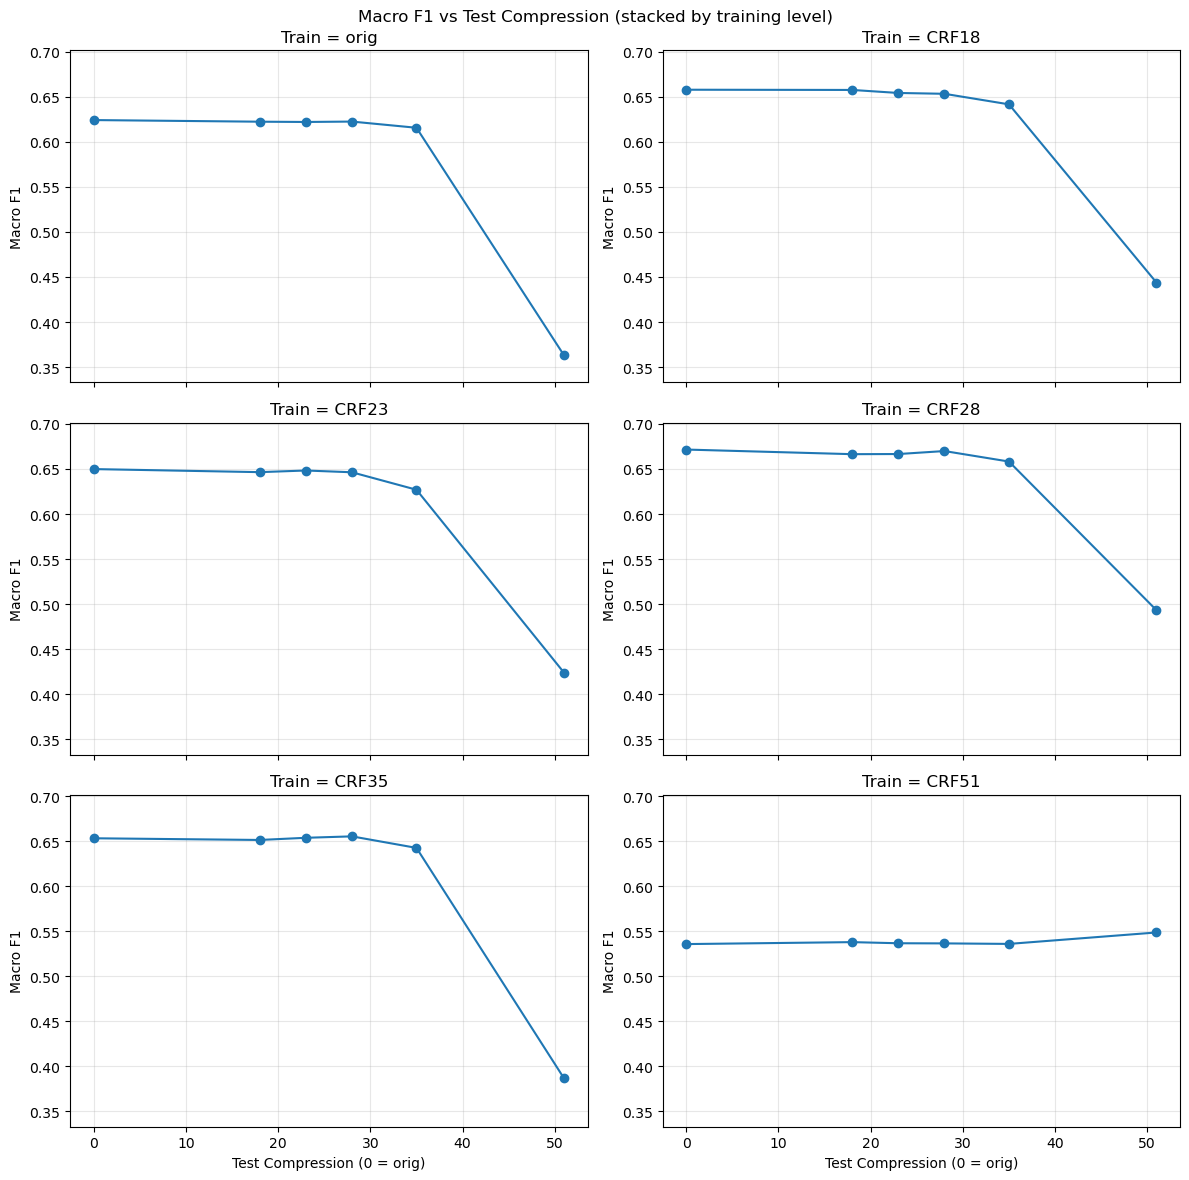

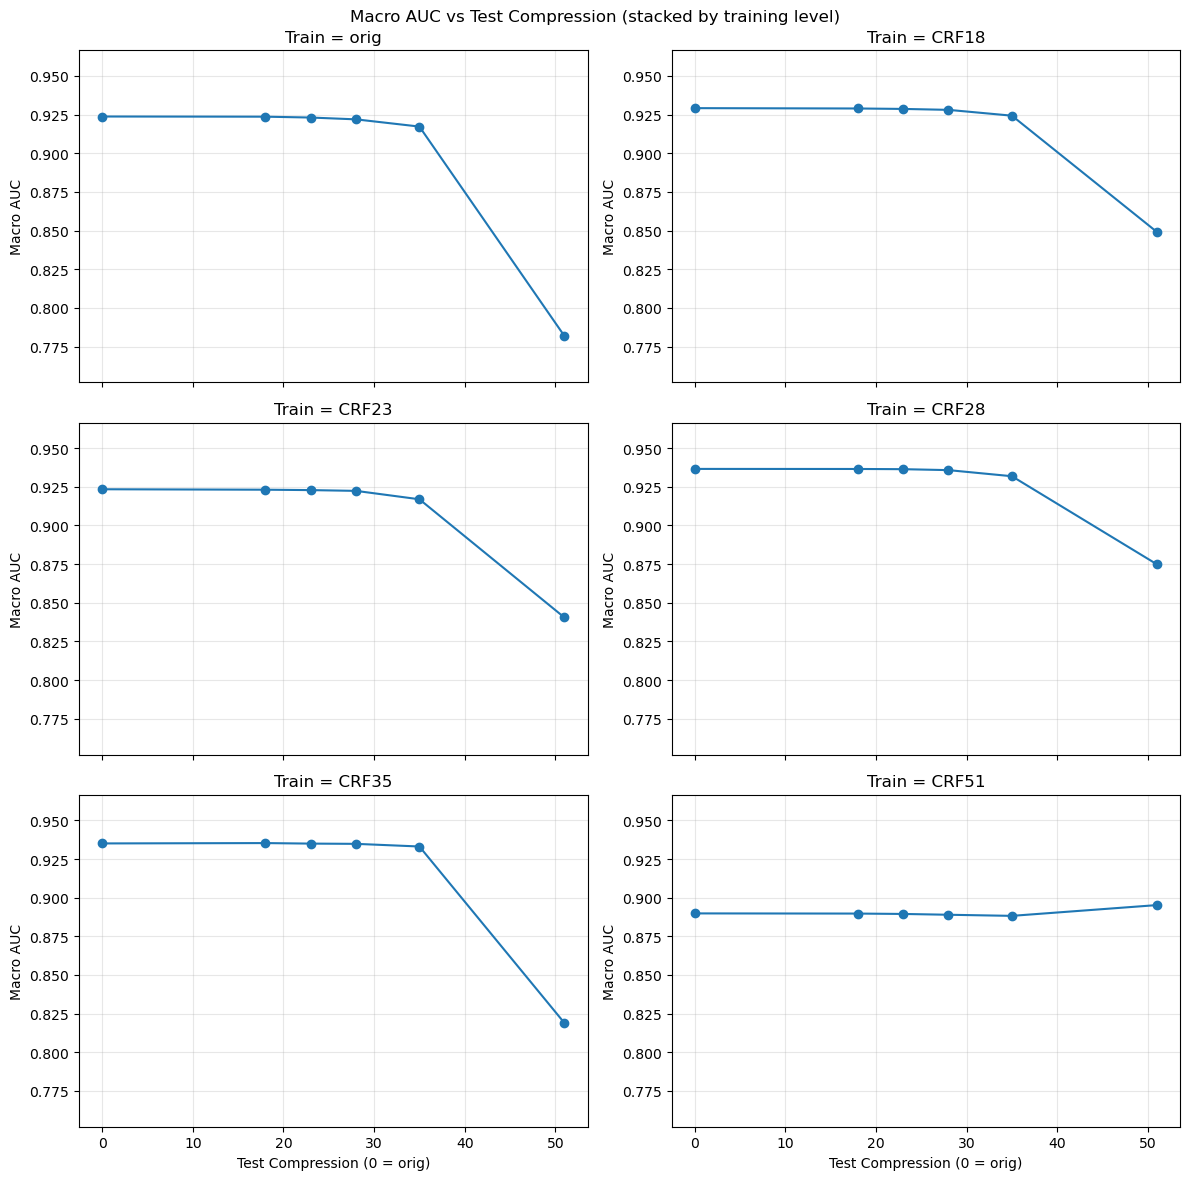

In [41]:
# ============================================================
# 16. Stacked line plot helper
# ============================================================
def stacked_metric_plot(metric_name, y_label, save_name):
    fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
    axes = axes.flatten()

    y_min = results_df[metric_name].min()
    y_max = results_df[metric_name].max()
    pad = 0.03

    for ax, train_level in zip(axes, LEVELS):
        subset = results_df[results_df["train_level"] == train_level].copy()
        subset["x"] = subset["test_level"].map(LEVEL_TO_X)
        subset = subset.sort_values("x")

        ax.plot(subset["x"], subset[metric_name], marker="o")
        ax.set_title(f"Train = {train_level}")
        ax.set_ylabel(y_label)
        ax.set_ylim(max(0, y_min - pad), min(1.0, y_max + pad))
        ax.grid(True, alpha=0.3)

    for ax in axes[-2:]:
        ax.set_xlabel("Test Compression (0 = orig)")

    plt.suptitle(f"{y_label} vs Test Compression (stacked by training level)")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / save_name, dpi=200)
    plt.show()

stacked_metric_plot("accuracy", "Accuracy", "stacked_accuracy_vs_test_compression.png")
stacked_metric_plot("precision_macro", "Macro Precision", "stacked_precision_vs_test_compression.png")
stacked_metric_plot("f1_macro", "Macro F1", "stacked_f1_vs_test_compression.png")
stacked_metric_plot("auc_macro_ovr", "Macro AUC", "stacked_auc_vs_test_compression.png")

## Diagonal-only matched train/test compression plots

In [42]:
# ============================================================
# 17. Diagonal metrics
# ============================================================
diagonal_rows = []
for level in LEVELS:
    row = results_df[
        (results_df["train_level"] == level) &
        (results_df["test_level"] == level)
    ].iloc[0].to_dict()
    row["x"] = LEVEL_TO_X[level]
    diagonal_rows.append(row)

diagonal_df = pd.DataFrame(diagonal_rows).sort_values("x").reset_index(drop=True)
diagonal_df.to_csv(METRICS_DIR / "diagonal_same_compression_metrics.csv", index=False)
diagonal_df

,train_level,test_level,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,loss,x
0,orig,orig,0.675330,0.645510,0.640907,0.624160,0.923796,1.321205,0
1,CRF18,CRF18,0.689019,0.639358,0.687920,0.657593,0.928983,1.292033,18
2,CRF23,CRF23,0.672255,0.669156,0.671291,0.648312,0.922889,1.324170,23
3,CRF28,CRF28,0.693384,0.647852,0.716279,0.669902,0.935812,1.078163,28
4,CRF35,CRF35,0.716100,0.652875,0.659365,0.642546,0.933106,1.060273,35
5,CRF51,CRF51,0.618887,0.565802,0.553072,0.548672,0.895211,1.295718,51


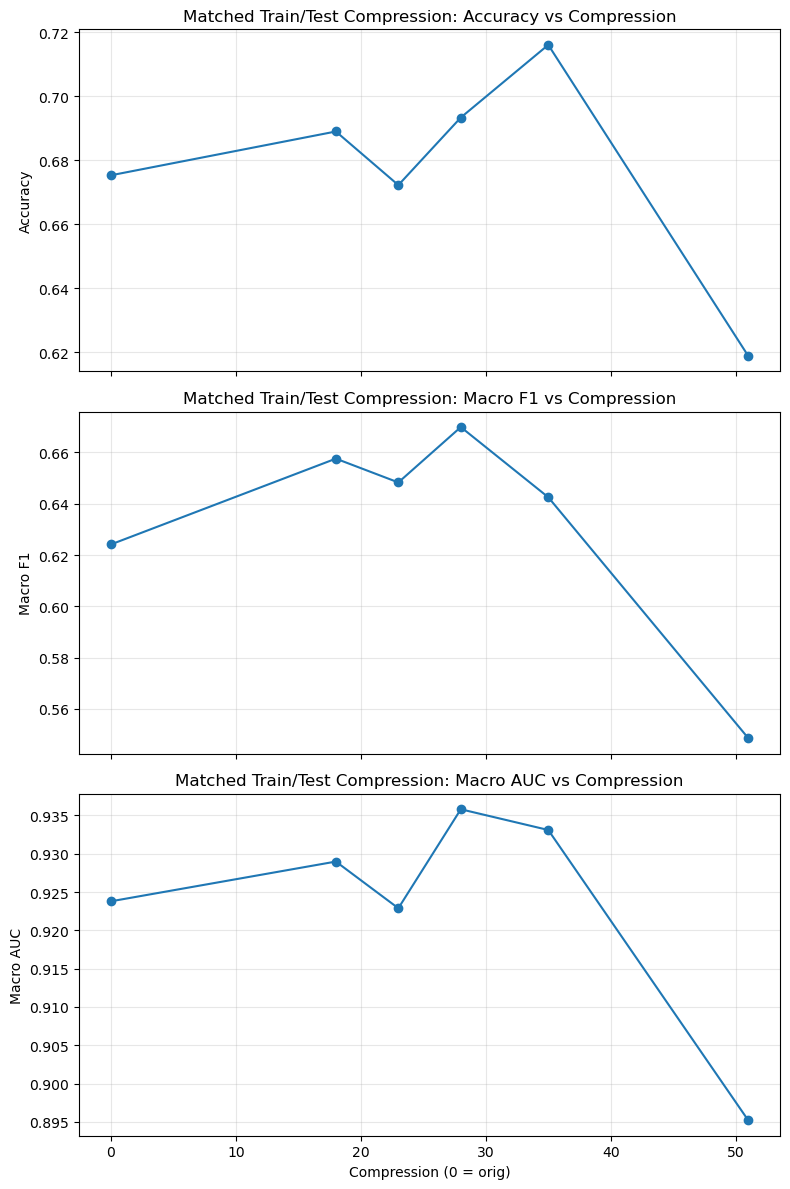

In [43]:
# ============================================================
# 18. Diagonal plots
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(diagonal_df["x"], diagonal_df["accuracy"], marker="o")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Matched Train/Test Compression: Accuracy vs Compression")
axes[0].grid(True, alpha=0.3)

axes[1].plot(diagonal_df["x"], diagonal_df["f1_macro"], marker="o")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Matched Train/Test Compression: Macro F1 vs Compression")
axes[1].grid(True, alpha=0.3)

axes[2].plot(diagonal_df["x"], diagonal_df["auc_macro_ovr"], marker="o")
axes[2].set_ylabel("Macro AUC")
axes[2].set_xlabel("Compression (0 = orig)")
axes[2].set_title("Matched Train/Test Compression: Macro AUC vs Compression")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "diagonal_metrics_vs_compression.png", dpi=200)
plt.show()

## Orig-trained curves only

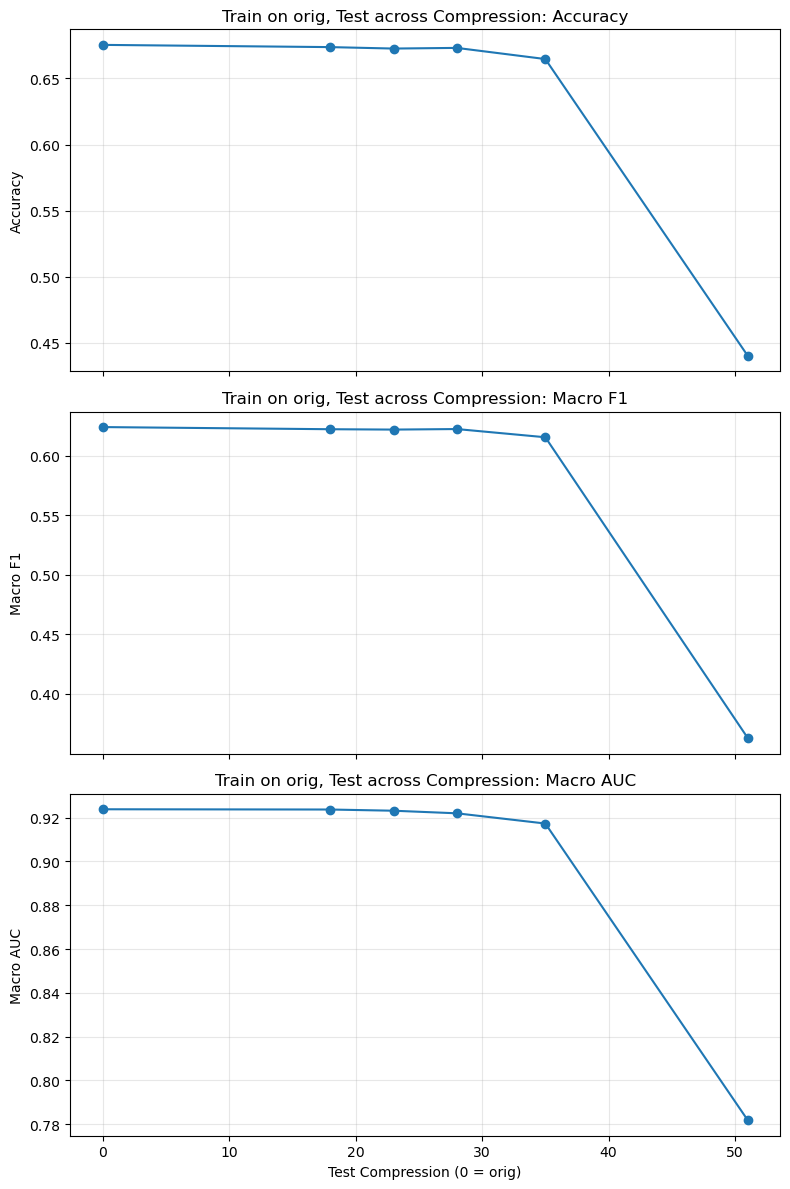

In [44]:
# ============================================================
# 19. Orig-trained curves
# ============================================================
orig_row_df = results_df[results_df["train_level"] == "orig"].copy()
orig_row_df["x"] = orig_row_df["test_level"].map(LEVEL_TO_X)
orig_row_df = orig_row_df.sort_values("x").reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(orig_row_df["x"], orig_row_df["accuracy"], marker="o")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Train on orig, Test across Compression: Accuracy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(orig_row_df["x"], orig_row_df["f1_macro"], marker="o")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Train on orig, Test across Compression: Macro F1")
axes[1].grid(True, alpha=0.3)

axes[2].plot(orig_row_df["x"], orig_row_df["auc_macro_ovr"], marker="o")
axes[2].set_ylabel("Macro AUC")
axes[2].set_xlabel("Test Compression (0 = orig)")
axes[2].set_title("Train on orig, Test across Compression: Macro AUC")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "orig_trained_metrics_vs_test_compression.png", dpi=200)
plt.show()

## Per-phase F1 stacked by training level

In [45]:
# ============================================================
# 20. Build per-phase results table
# ============================================================
phase_rows = []
for (train_level, test_level), m in all_results.items():
    for phase_name, phase_f1 in m["per_class_f1"].items():
        phase_rows.append({
            "train_level": train_level,
            "test_level": test_level,
            "phase_name": phase_name,
            "phase_f1": phase_f1,
            "x": LEVEL_TO_X[test_level],
        })

phase_df = pd.DataFrame(phase_rows)
phase_df.to_csv(METRICS_DIR / "per_phase_f1_cross_compression.csv", index=False)
phase_df.head()

,train_level,test_level,phase_name,phase_f1,x
0,orig,orig,Preparation,0.432432,0
1,orig,orig,CalotTriangleDissection,0.703019,0
2,orig,orig,ClippingCutting,0.737643,0
3,orig,orig,GallbladderDissection,0.680028,0
4,orig,orig,GallbladderPackaging,0.581176,0


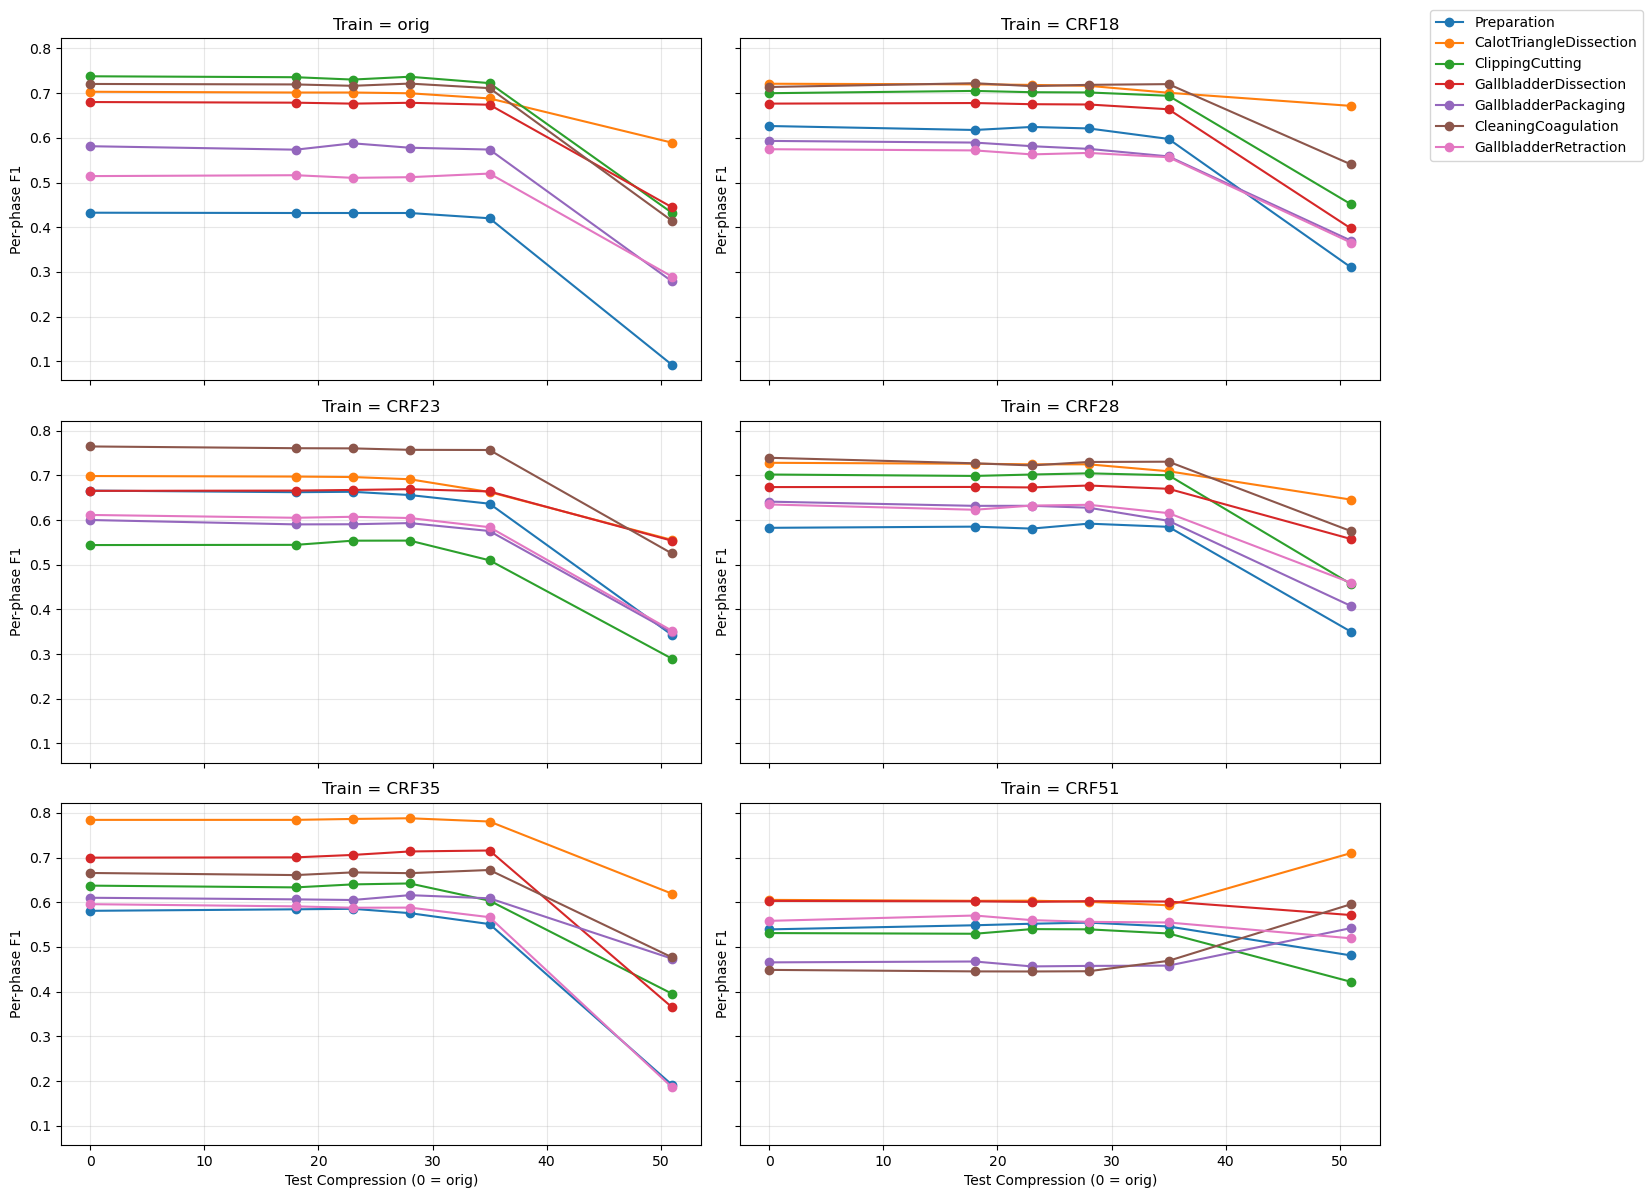

In [46]:
# ============================================================
# 21. Per-phase stacked plot
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, train_level in zip(axes, LEVELS):
    subset = phase_df[phase_df["train_level"] == train_level].copy()

    for phase_name in PHASE_MAP.keys():
        s = subset[subset["phase_name"] == phase_name].sort_values("x")
        ax.plot(s["x"], s["phase_f1"], marker="o", label=phase_name)

    ax.set_title(f"Train = {train_level}")
    ax.set_ylabel("Per-phase F1")
    ax.grid(True, alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel("Test Compression (0 = orig)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "stacked_per_phase_f1_vs_test_compression.png", dpi=200)
plt.show()

## Selected confusion matrices

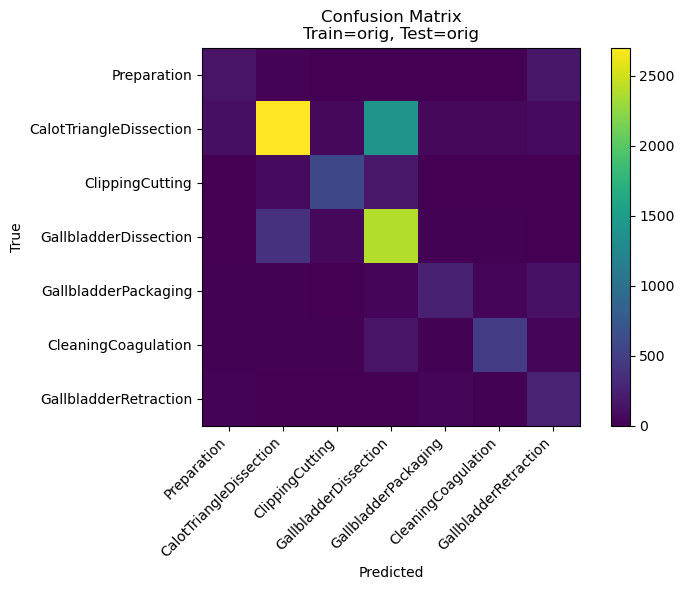

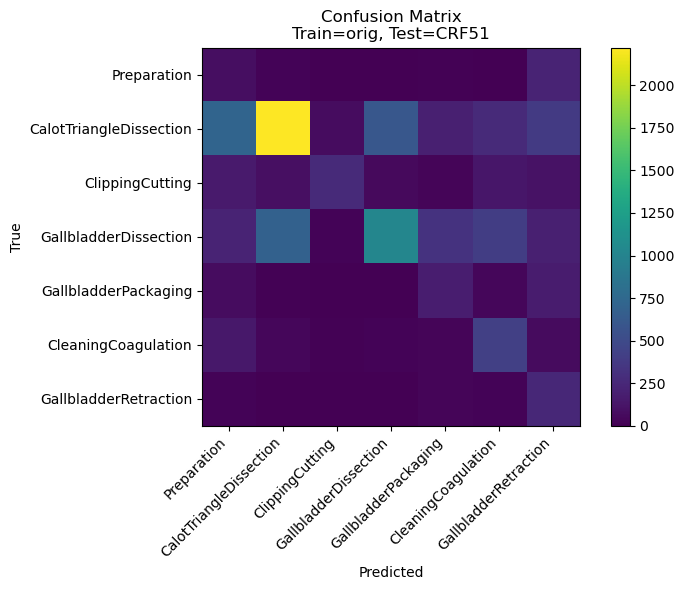

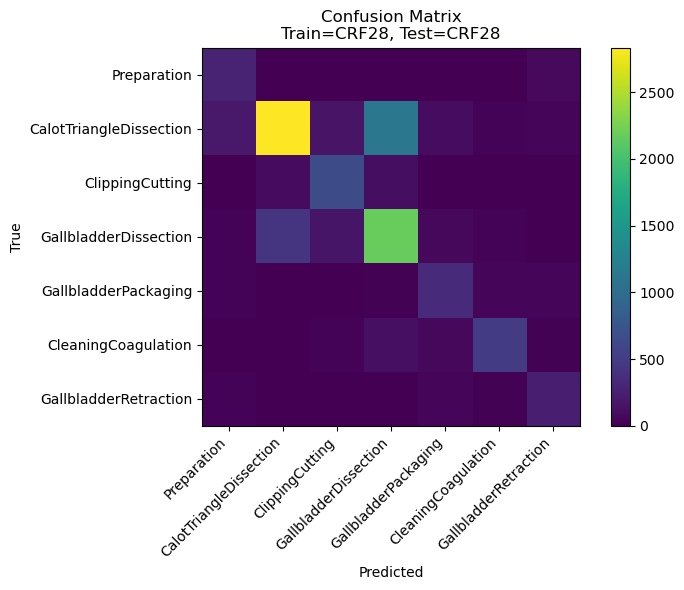

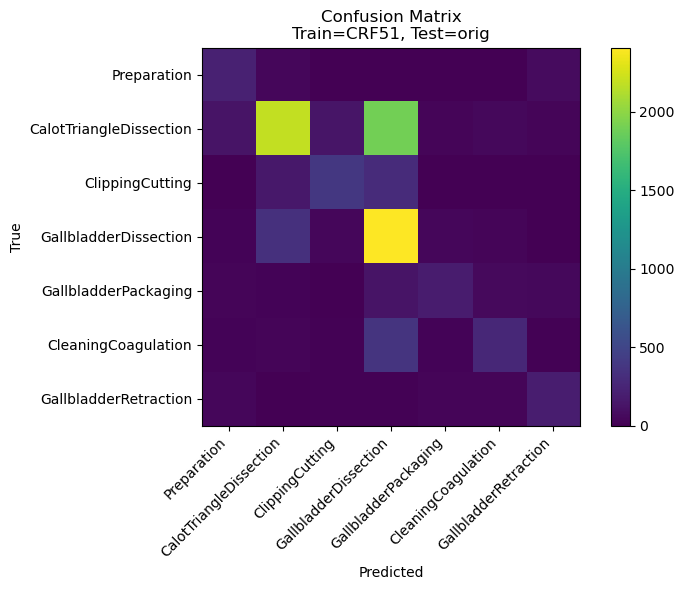

In [47]:
# ============================================================
# 22. Confusion matrix helper
# ============================================================
def plot_confusion_for_pair(train_level, test_level):
    pred_df = all_pred_tables[(train_level, test_level)]
    y_true = pred_df["y_true"].values
    y_pred = pred_df["y_pred"].values

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix\nTrain={train_level}, Test={test_level}")
    plt.colorbar()

    ticks = np.arange(NUM_CLASSES)
    names = [ID_TO_PHASE[i] for i in range(NUM_CLASSES)]
    plt.xticks(ticks, names, rotation=45, ha="right")
    plt.yticks(ticks, names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"confusion_train_{train_level}__test_{test_level}.png", dpi=200)
    plt.show()

selected_pairs = [
    ("orig", "orig"),
    ("orig", "CRF51"),
    ("CRF28", "CRF28"),
    ("CRF51", "orig"),
]

for pair in selected_pairs:
    plot_confusion_for_pair(*pair)

## Selected ROC curves

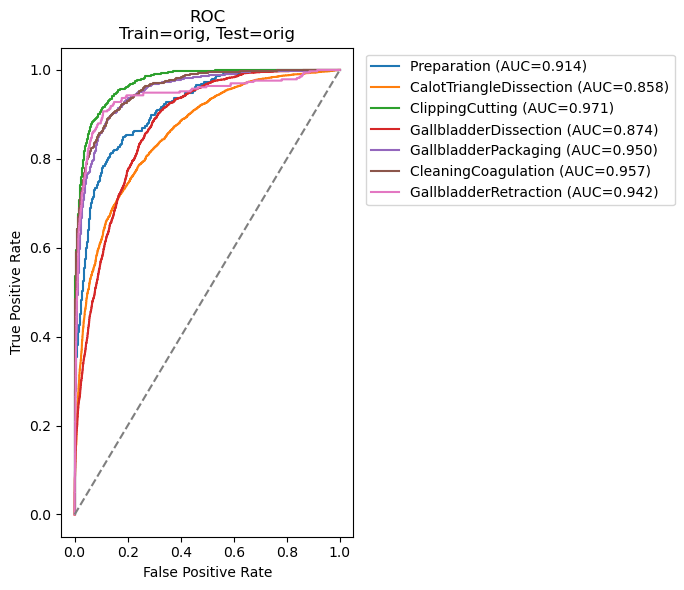

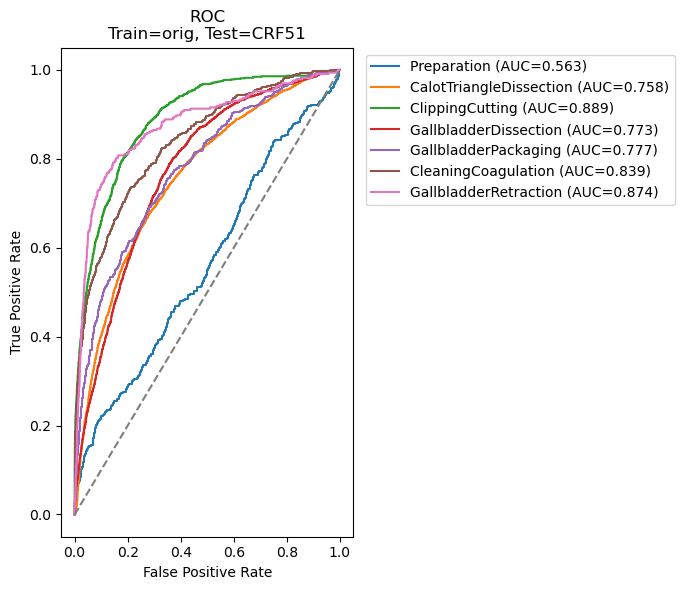

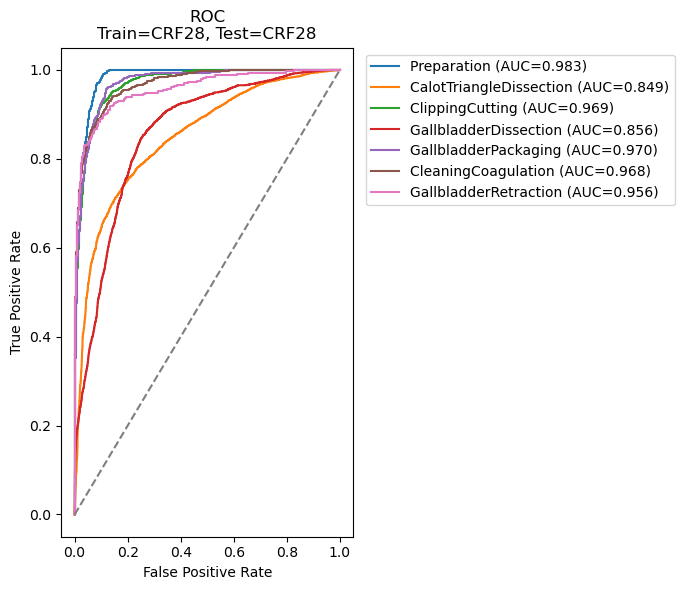

In [48]:
# ============================================================
# 23. ROC helper
# ============================================================
def plot_roc_for_pair(train_level, test_level):
    pred_df = all_pred_tables[(train_level, test_level)]
    y_true = pred_df["y_true"].values
    y_prob = pred_df[[f"prob_{ID_TO_PHASE[i]}" for i in range(NUM_CLASSES)]].values
    y_true_oh = np.eye(NUM_CLASSES)[y_true]

    plt.figure(figsize=(7, 6))

    for c in range(NUM_CLASSES):
        try:
            fpr, tpr, _ = roc_curve(y_true_oh[:, c], y_prob[:, c])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{ID_TO_PHASE[c]} (AUC={roc_auc:.3f})")
        except Exception:
            pass

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC\nTrain={train_level}, Test={test_level}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"roc_train_{train_level}__test_{test_level}.png", dpi=200)
    plt.show()

for pair in [("orig", "orig"), ("orig", "CRF51"), ("CRF28", "CRF28")]:
    plot_roc_for_pair(*pair)

## Grad-CAM

In [49]:
# ============================================================
# 24. Grad-CAM
# ============================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handles = []

        self.handles.append(target_layer.register_forward_hook(self._forward_hook))
        self.handles.append(target_layer.register_full_backward_hook(self._backward_hook))

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove(self):
        for h in self.handles:
            h.remove()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)

        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        score = logits[:, class_idx]
        self.model.zero_grad()
        score.backward(retain_graph=True)

        grads = self.gradients[0]
        acts = self.activations[0]
        weights = grads.mean(dim=(1, 2))

        cam = torch.zeros(acts.shape[1:], device=acts.device)
        for c, w in enumerate(weights):
            cam += w * acts[c]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy(), class_idx

In [50]:
# ============================================================
# 25. Grad-CAM helpers
# ============================================================
def load_eval_image(path):
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)
    return img, x

def get_prediction_row(train_level, test_level, video, second_idx):
    df = all_pred_tables[(train_level, test_level)]
    row = df[
        (df["video"] == video) &
        (df["second_idx"].astype(int) == int(second_idx))
    ]
    if len(row) == 0:
        return None
    return row.iloc[0]

In [51]:
# ============================================================
# 26. Load one trained model for Grad-CAM
# ============================================================
GRADCAM_TRAIN_LEVEL = "orig"

gradcam_model = build_model().to(DEVICE)
gradcam_ckpt = torch.load(CHECKPOINT_DIR / f"best_resnet18_train_{GRADCAM_TRAIN_LEVEL}.pth", map_location=DEVICE)
gradcam_model.load_state_dict(gradcam_ckpt["model_state_dict"])
gradcam_model.eval()

gradcam = GradCAM(gradcam_model, gradcam_model.layer4[-1])

print("Loaded Grad-CAM model trained on:", GRADCAM_TRAIN_LEVEL)

Loaded Grad-CAM model trained on: orig


In [52]:
# ============================================================
# 27. Grad-CAM comparison function
# ============================================================
def show_gradcam_comparison(train_level, video, second_idx, test_levels=("orig", "CRF18", "CRF28", "CRF51"), use_pred_class=True):
    n = len(test_levels)
    plt.figure(figsize=(4 * n, 8))

    for i, test_level in enumerate(test_levels, start=1):
        row = get_prediction_row(train_level, test_level, video, second_idx)
        if row is None:
            continue

        pil_img, x = load_eval_image(row["image_path"])
        class_idx = int(row["y_pred"]) if use_pred_class else int(row["y_true"])
        cam, used_class = gradcam(x, class_idx=class_idx)

        raw_img = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)))

        plt.subplot(2, n, i)
        plt.imshow(raw_img)
        plt.axis("off")
        plt.title(f"Test={test_level}\nTrue={row['y_true_name']}\nPred={row['y_pred_name']}")

        plt.subplot(2, n, i + n)
        plt.imshow(raw_img)
        plt.imshow(cam, alpha=0.4)
        plt.axis("off")
        plt.title(f"Grad-CAM ({ID_TO_PHASE[used_class]})")

    plt.suptitle(f"Train={train_level} | {video} | second_idx={second_idx}")
    plt.tight_layout()

    save_path = GRADCAM_DIR / f"gradcam_train_{train_level}__{video}_sec{second_idx}.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)

In [53]:
# ============================================================
# 28. Pick candidate orig-orig correct examples
# ============================================================
orig_orig_correct = all_pred_tables[("orig", "orig")].copy()
orig_orig_correct = orig_orig_correct[orig_orig_correct["y_true"] == orig_orig_correct["y_pred"]]

orig_orig_correct[["video", "second_idx", "y_true_name", "y_pred_name"]].head(20)

,video,second_idx,y_true_name,y_pred_name
10,video16,tensor(10),Preparation,Preparation
13,video16,tensor(13),Preparation,Preparation
17,video16,tensor(17),Preparation,Preparation
20,video16,tensor(20),Preparation,Preparation
21,video16,tensor(21),Preparation,Preparation
22,video16,tensor(22),Preparation,Preparation
23,video16,tensor(23),Preparation,Preparation
24,video16,tensor(24),Preparation,Preparation
25,video16,tensor(25),Preparation,Preparation
27,video16,tensor(27),Preparation,Preparation


In [54]:
# ============================================================
# 29. Example Grad-CAM call
# ============================================================
# Replace with a real example from the table above
# show_gradcam_comparison(train_level="orig", video="video16", second_idx=100)